### Importing libraries

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading dataset

In [72]:
df=pd.DataFrame(pd.read_csv("data/sales_data.csv"))

### Shape & Size of dataset

In [73]:
print(f"Shape of the dataset : {df.shape}\n")
print(f"No.of rows/entries in the dataset : {df.shape[0]}")

Shape of the dataset : (100, 7)

No.of rows/entries in the dataset : 100


### Information about the dataset

In [74]:
col=df.columns
print(f"Columns in the dataset : \n{pd.Series(col)}\n")
print(f"Data types of the columns : \n{df.dtypes}\n")

Columns in the dataset : 
0           Date
1        Product
2       Quantity
3          Price
4    Customer_ID
5         Region
6    Total_Sales
dtype: str

Data types of the columns : 
Date             str
Product          str
Quantity       int64
Price          int64
Customer_ID      str
Region           str
Total_Sales    int64
dtype: object



### Unique entries in REGION

In [75]:
uni_region=df["Region"].unique()
print(f"Unique regions in the dataset : \n{pd.Series(uni_region)}")

Unique regions in the dataset : 
0     East
1    North
2     West
3    South
dtype: str


### Unique entries in PRODUCT

In [76]:
uni_prod=df['Product'].unique()
print(f"Unique products in the dataset : \n{pd.Series(uni_prod)}")

Unique products in the dataset : 
0         Phone
1    Headphones
2        Laptop
3        Tablet
4       Monitor
dtype: str


### Region-wise quantity analysis

In [77]:
print(f"Average amount of quantity sold overall: {df['Quantity'].mean()}")

Average amount of quantity sold overall: 4.78


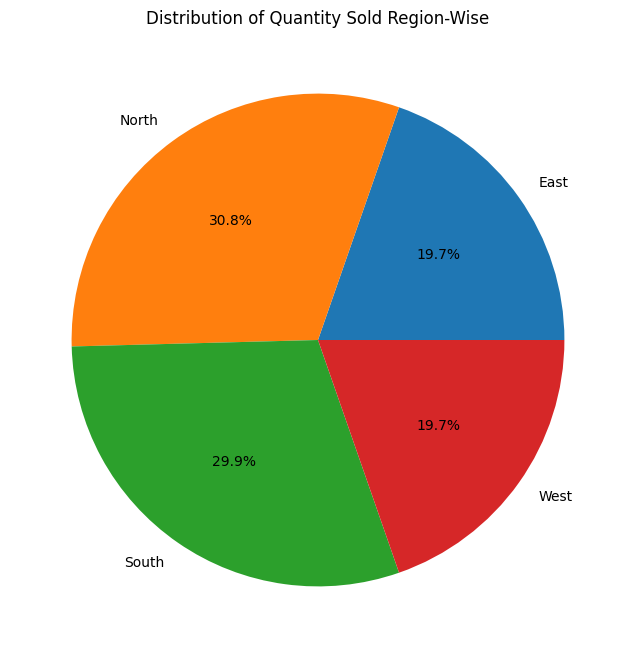

In [78]:
region_wise_sum=df.groupby("Region")["Quantity"].sum()
plt.figure(figsize=(8,8))
plt.pie(region_wise_sum, labels=region_wise_sum.index, autopct='%1.1f%%')
plt.title('Distribution of Quantity Sold Region-Wise')
plt.show()

In [79]:
region_wise_avg=df.groupby("Region")["Quantity"].mean()
print(f"Region-wise average quantity sold : \n{region_wise_avg}")

Region-wise average quantity sold : 
Region
East     4.947368
North    5.250000
South    5.296296
West     3.615385
Name: Quantity, dtype: float64


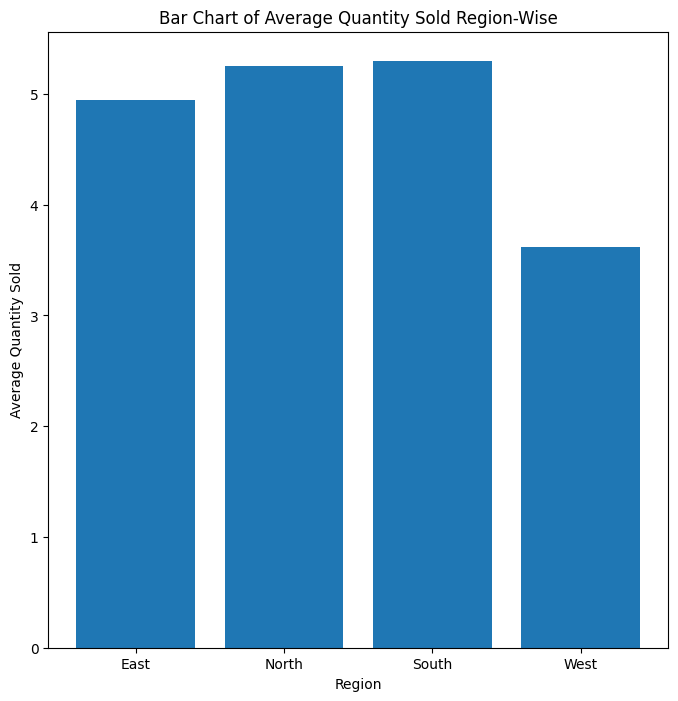

In [80]:
plt.figure(figsize=(8,8))
plt.bar(region_wise_avg.index, region_wise_avg.values)
plt.xlabel('Region')
plt.ylabel('Average Quantity Sold')
plt.title('Bar Chart of Average Quantity Sold Region-Wise')
plt.show()

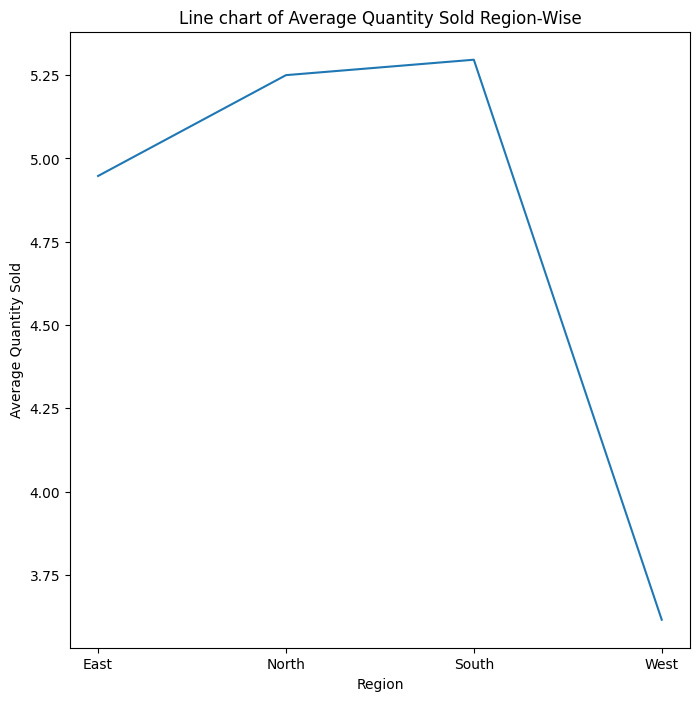

In [81]:
plt.figure(figsize=(8,8))
plt.plot(region_wise_avg.index, region_wise_avg.values)
plt.xlabel('Region')
plt.ylabel('Average Quantity Sold')
plt.title('Line chart of Average Quantity Sold Region-Wise')
plt.show()

### Region-wise Sales analysis

In [82]:
print(f"Total sales amount overall : ₹{df['Total_Sales'].sum()}")

Total sales amount overall : ₹12365048


In [83]:
print(f"Average sales amount overall: ₹{df['Total_Sales'].mean()}\n")

Average sales amount overall: ₹123650.48



In [84]:
sales_regionwise=df.groupby('Region')['Total_Sales'].sum()
print(f"Total region-wise sales amount :\n{sales_regionwise}")

Total region-wise sales amount :
Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64


In [85]:
avg_sales_regionwise=df.groupby('Region')['Total_Sales'].mean()
print(f"Average region-wise sales amount :\n{avg_sales_regionwise}")

Average region-wise sales amount :
Region
East     132612.578947
North    142272.678571
South    138438.962963
West      81689.307692
Name: Total_Sales, dtype: float64


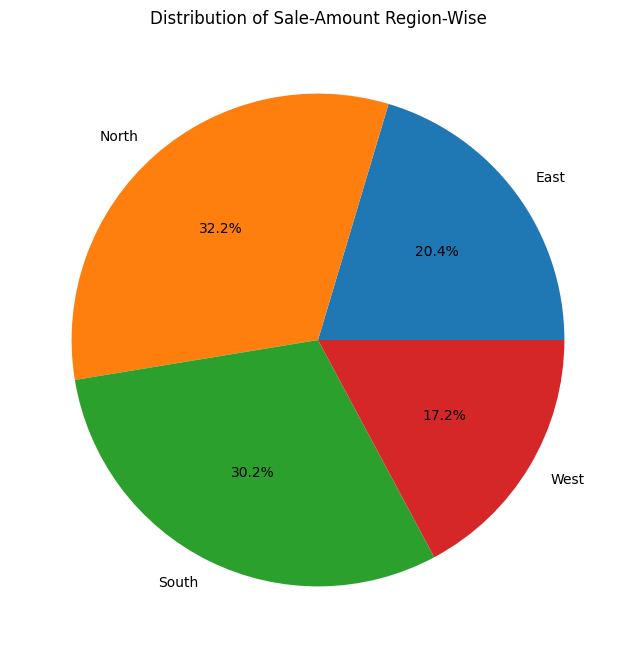

In [86]:
plt.figure(figsize=(8,8))
plt.pie(sales_regionwise, labels=sales_regionwise.index, autopct='%1.1f%%')
plt.title('Distribution of Sale-Amount Region-Wise')
plt.show()

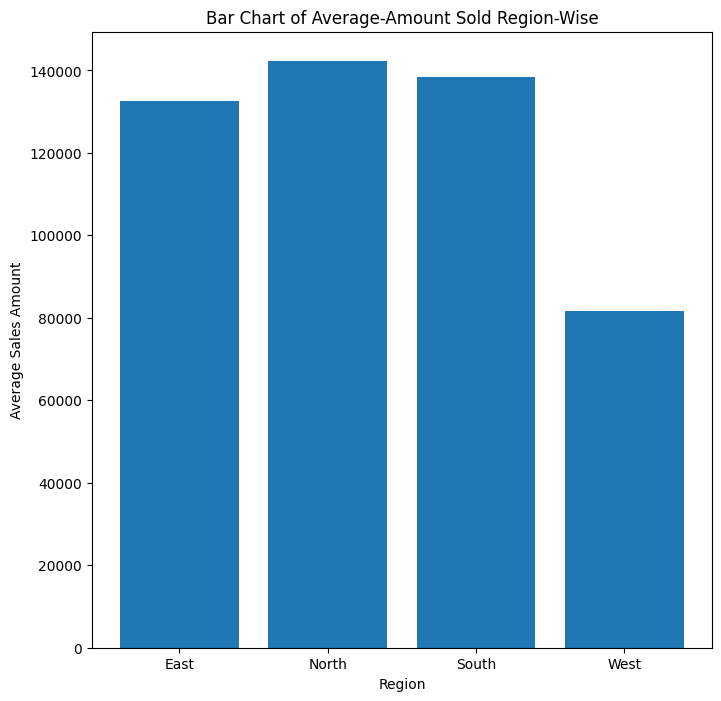

In [87]:
plt.figure(figsize=(8,8))
plt.bar(avg_sales_regionwise.index, avg_sales_regionwise.values)
plt.title('Bar Chart of Average-Amount Sold Region-Wise')
plt.xlabel('Region')
plt.ylabel('Average Sales Amount')
plt.show()

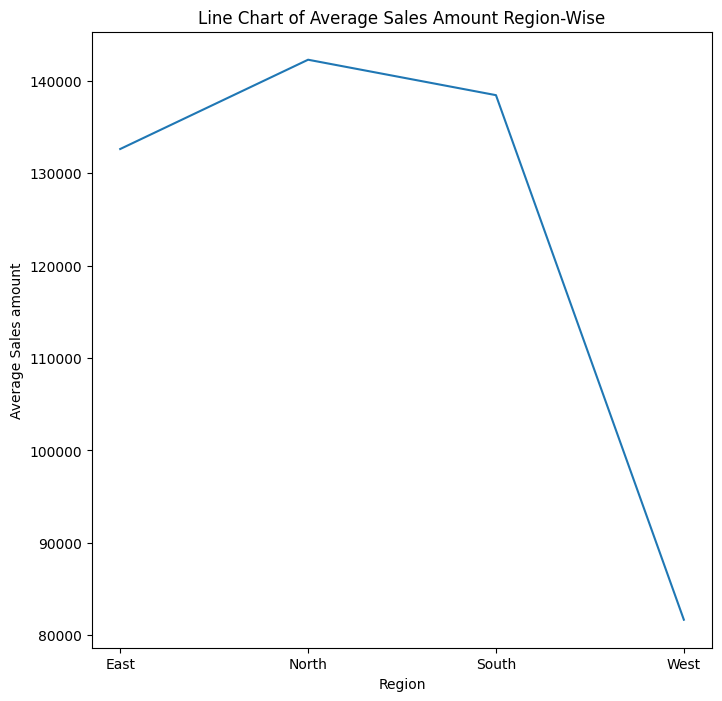

In [88]:
plt.figure(figsize=(8,8))
plt.plot(avg_sales_regionwise.index, avg_sales_regionwise.values)
plt.title('Line Chart of Average Sales Amount Region-Wise')
plt.xlabel('Region')
plt.ylabel('Average Sales amount')
plt.show()

### Product-wise Quantity analysis

In [89]:
prod_quantity=df.groupby('Product')['Quantity'].sum()
print(f"Total quantity sold product-wise :\n{prod_quantity}")

Total quantity sold product-wise :
Product
Headphones     48
Laptop        136
Monitor        66
Phone         101
Tablet        127
Name: Quantity, dtype: int64


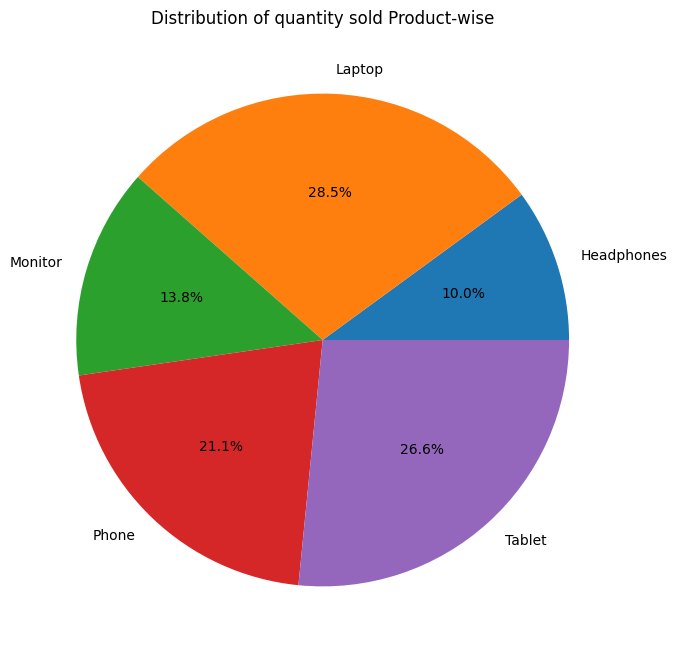

In [90]:
plt.figure(figsize=(8,8))
plt.pie(prod_quantity.values, labels=prod_quantity.index, autopct='%1.1f%%')
plt.title('Distribution of quantity sold Product-wise')
plt.show()

### Product-wise Sales analysis

#### Overall sale

In [91]:
prod_sale=df.groupby('Product')['Total_Sales'].sum()
print(f"Total sales amount product-wise :\n{prod_sale}")

Total sales amount product-wise :
Product
Headphones    1384033
Laptop        3889210
Monitor       1348071
Phone         2859394
Tablet        2884340
Name: Total_Sales, dtype: int64


#### Average sale

In [92]:
avg_prod_sale=df.groupby('Product')['Total_Sales'].mean()
print(f"Average sales amount product-wise :\n{avg_prod_sale}")

Average sales amount product-wise :
Product
Headphones     92268.866667
Laptop        162050.416667
Monitor        89871.400000
Phone         142969.700000
Tablet        110936.153846
Name: Total_Sales, dtype: float64


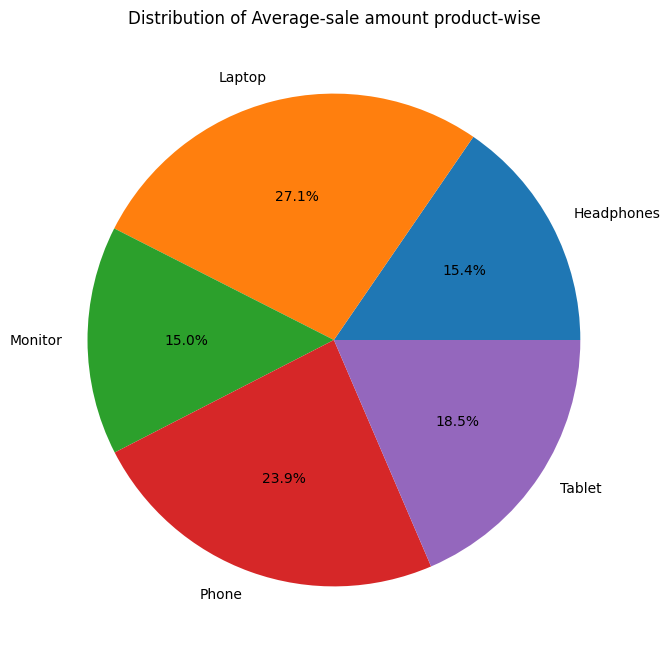

In [93]:
plt.figure(figsize=(8,8))
plt.pie(avg_prod_sale.values, labels=avg_prod_sale.index, autopct='%1.1f%%')
plt.title('Distribution of Average-sale amount product-wise')
plt.show()

### Grouping by Date

### Monthly sale analysis

#### Converting date data type

In [105]:
df['Date']=pd.to_datetime(df['Date'])
print(f"Data type of 'Date' column: {df['Date'].dtype}")

Data type of 'Date' column: datetime64[us]


#### Month-wise overall sales analysis

In [106]:
monthly_sale=df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sale.index=monthly_sale.index.strftime('%B %Y')

print(f"Monthly sales amount :\n{monthly_sale}")

Monthly sales amount :
Date
January 2024     4120524
February 2024    2656050
March 2024       4485006
April 2024       1103468
Name: Total_Sales, dtype: int64


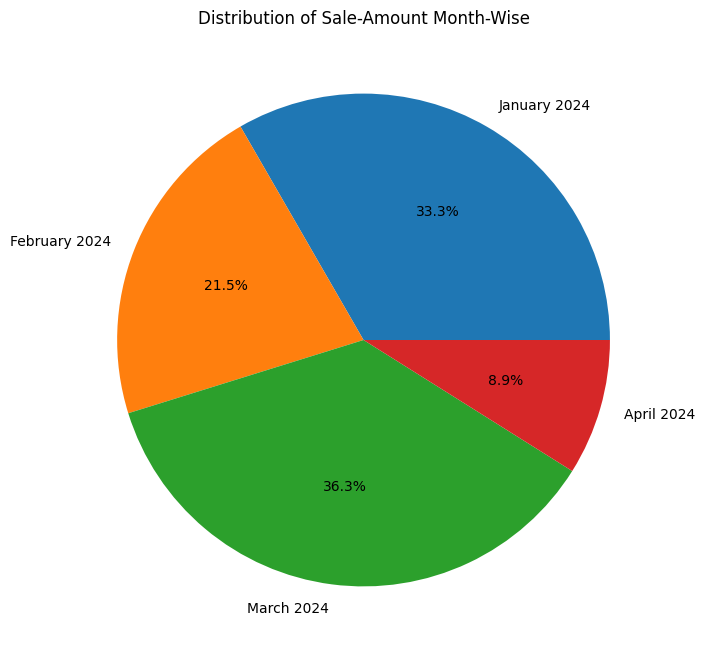

In [107]:
plt.figure(figsize=(8,8))
plt.pie(monthly_sale, labels=monthly_sale.index, autopct='%1.1f%%')
plt.title('Distribution of Sale-Amount Month-Wise')
plt.show()

#### Month-wise average sales analysis

In [108]:
avg_monthly_sale=df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].mean()
avg_monthly_sale.index=avg_monthly_sale.index.strftime('%B %Y')

print(f"Average monthly sales amount :\n{avg_monthly_sale}")

Average monthly sales amount :
Date
January 2024     132920.129032
February 2024     91587.931034
March 2024       144677.612903
April 2024       122607.555556
Name: Total_Sales, dtype: float64


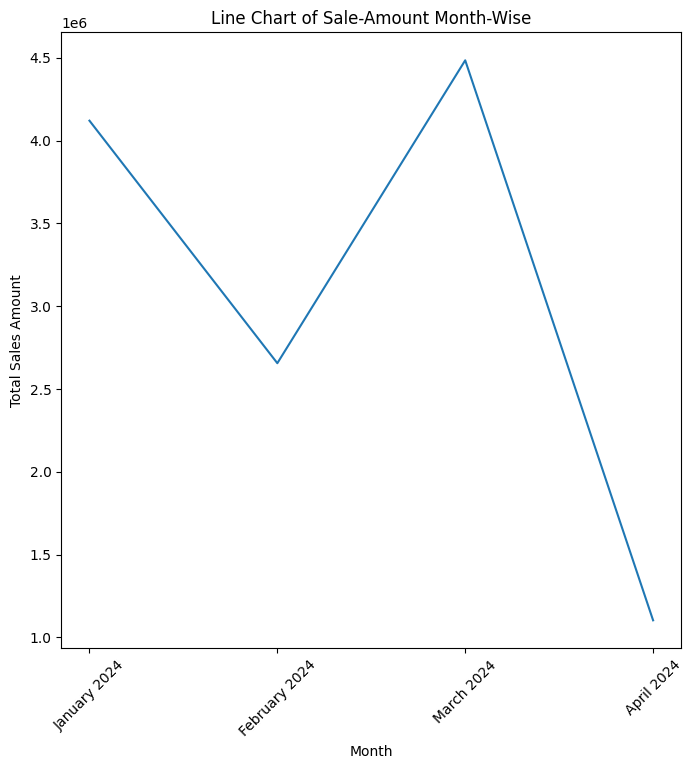

In [111]:
plt.figure(figsize=(8,8))
plt.plot(monthly_sale.index, monthly_sale.values)
plt.title('Line Chart of Sale-Amount Month-Wise')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Total Sales Amount')
plt.show()